# Test d'hypothèses

# Résumé
---
À partir de notre échantillon, nous posons une hypothèse nulle $H_0$ (par exemple $\mu = 5$) que nous soumettons à un test de cohérence mathématique face à une hypothèse alternative $H_1$ (ex: $\mu \neq 5$). Cette méthode repose sur la construction d'une statistique de test $g(x_1, \dots, x_n)$, dont la loi de probabilité sous $H_0$ doit être connue (comme une loi Gaussienne ou de Student), permettant de déterminer si les données observées sont probables ou si elles tombent dans une zone de rejet. Dans ce travail, l'application de cette rigueur — s'appuyant sur l'estimation du maximum de vraisemblance pour définir nos paramètres et l'usage de tests de comparaison pour les loutres — nous a permis de transformer des mesures brutes en conclusions scientifiques. En somme, si le résultat de la statistique est trop éloigné de ce qui est attendu sous $H_0$, nous rejetons cette hypothèse pour signifier que l'échantillon ne la vérifie pas ; à l'inverse, l'absence de rejet nous indique que les variations observées peuvent être simplement attribuées au hasard de l'échantillonnage, garantissant ainsi une gestion rigoureuse du risque d'erreur $\alpha$.

In [1]:
#données sur poids des loutres
poids=c(5.71,4.29,3.46,3.09,2.69,4.88,5.77,4.90,4.27,5.14,3.96,4.91,4.74,5.81)

In [2]:
x=mean(poids)
x

[1] 4.544286

Moyenne de référence des loutres en France : 5

H0:la moyenne des poids des loutres du pparc et la meme que celle de la moyenne de l'espèce

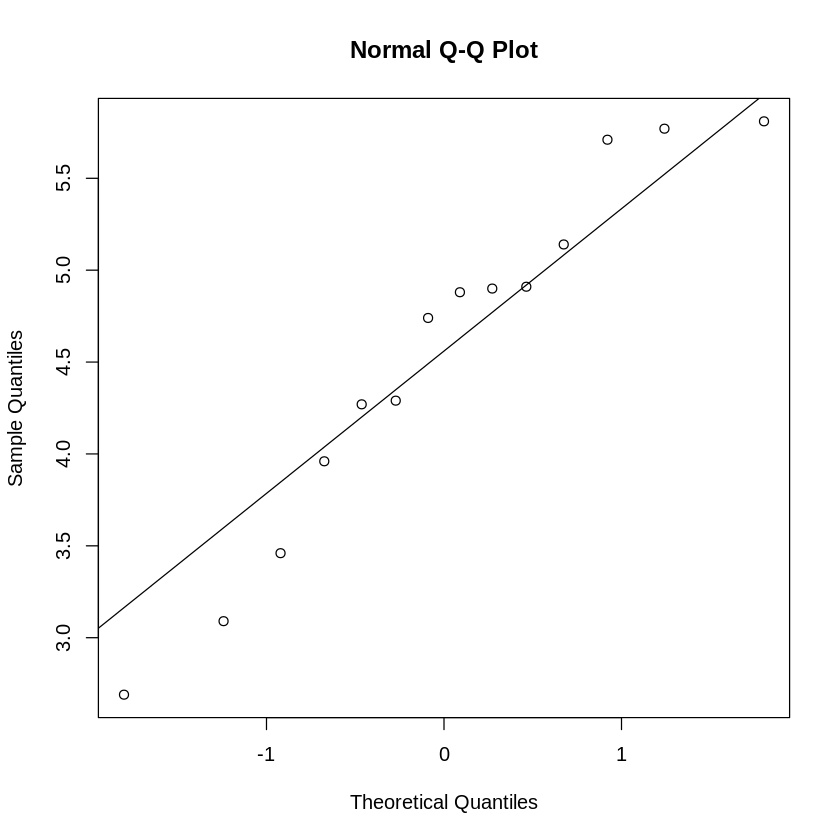

In [3]:
qqnorm(poids)
qqline(poids)

plus les point se repproche de la mediatrices(la droite) plus on se repproche de la loi ici loi gaussienne (affichage données et quantile de notre echantillon et quantile thorique de la loi normale )

p_valeur
une proba sous H0 d'observé les données obtenus ,à quels point ce que j'ai obtenu et est probable ,plus cette valeur est grande plus c'est probable ,si p valeur est petite c'est un ca extremme donc on rejette


p_valeur=2*P(Z<abs(Z observer))
=2(1-Fz(abs(Z observer)))


test de student
-on veut obtenir une loi , tcl ou test de student , hypothese qu'on fait sur les données independant, distribué normalement , moyenne et données gaussienne test de student:


ondivise par une estimateur de la variance non biaisé (voir ennoncé j'ai ecrit les element pour répondre à la question 1

### Test de Student (Comparaison de moyenne)

**Statistique de test :**
$$Z = \frac{\sqrt{m}(\bar{X}_m - \mu)}{S^*_m} \sim \mathcal{T}(m-1)$$

**Calcul de la variance échantillonnale :**
$$(S^*_m)^2 = \frac{1}{m-1} \sum_{i=1}^{m} (X_i - \bar{X}_m)^2$$

**Règle de décision :**
Sous $H_0$, $\alpha$ est la probabilité qu'on se trompe. La zone de rejet pour un test bilatéral est :
$$\mathcal{R} = \{ |Z| > q_{1-\alpha/2} \}$$

On chosit la statique de test de student,car on est dans le cas test de compararaison à une moyenne de référence.

In [4]:
#3
#p valeur
# help(pt)
m=14
mu=5
Z=(sqrt(m)*(x-mu))/sqrt(var(poids))#var(poids) c'est l'estimateur de la variance
print(abs(Z))
p_value=2*(1-pt(abs(Z),13))#m-1=13 ,degrès de la loi de student
p_value

[1] 1.743101


[1] 0.1049026

### Explication et utilisation de la table de student
---
Concernant la zone de rejet,notre est alpha =10% (0.1),afin de  calculer le quantile, on divise par deux car on est dans un cas bilatérale c'est à dire on veut que la moyenne soit exactement égale à 5.En suite,en se basant nos données,on a un degrès de liberté 13, et un quantile alpha/2 et comme on est dans le cas bilaterale donc 0.1 /2 =0.05 ,alors d'après la table de la loi de student.

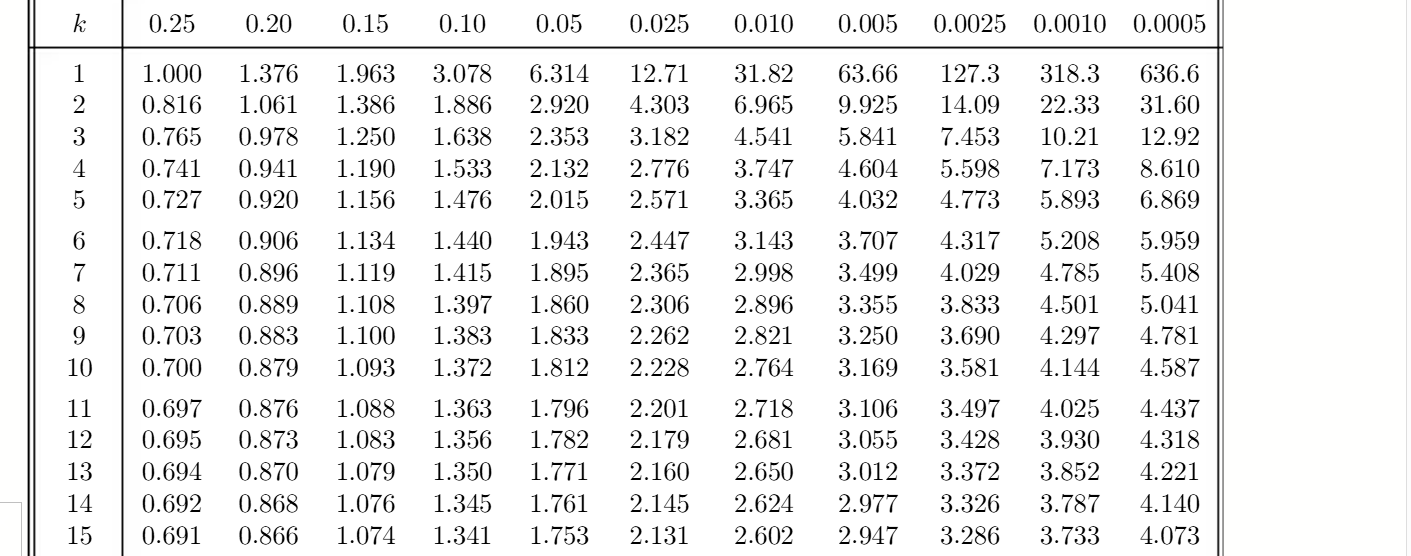

d'après notre zone de rejet :
$$\mathcal{R} = \{ |Z| > q_{1-\alpha/2} \}$$

comme on est notre seuil ici est alpha =0.1 est on est dans une hypothèse bilateral alors on prend alpha/2 =0.1/2=0.05,d'après le tableau

$$\{q_{1-\alpha/2} = 1.771 \}$$
et |Z| =1.743101

Cela prouve qu'on est à la limite de la zone de sécurité car $$\{|Z| < q_{1-\alpha/2} \}$$
donc on garde notre hypothèse H0.

Aussi,on garde l'hypothese H0 car le résultat de la p_value 0.104902575486094>0.1 qui est le seuils en statistiques énoncé pour erronée une hypothese n'est pas dépassé.

In [5]:
t.test(poids,mu=5)


	One Sample t-test

data:  poids
t = -1.7431, df = 13, p-value = 0.1049
alternative hypothesis: true mean is not equal to 5
95 percent confidence interval:
 3.979482 5.109090
sample estimates:
mean of x 
 4.544286 


Cette commande calcul directement ce qu'on a fait étape par étape juste avant et on obtient le meme résulat et donc la meme conclusion.

Voici notre zone de rejet avec une hypothese bilateral:
On suppose maintenant que H0 avec un alpha 0.05 (dans l'illustration ):

H0:la moyenne du poids des loutres du parc est inférieurs ou égale à celle de l'espèce . Donc ici on passe à une hypothèse **unilaterale**,c'est à dire notre alpha n'est pas divisé par 2 (ici alpha on prend =0.1).

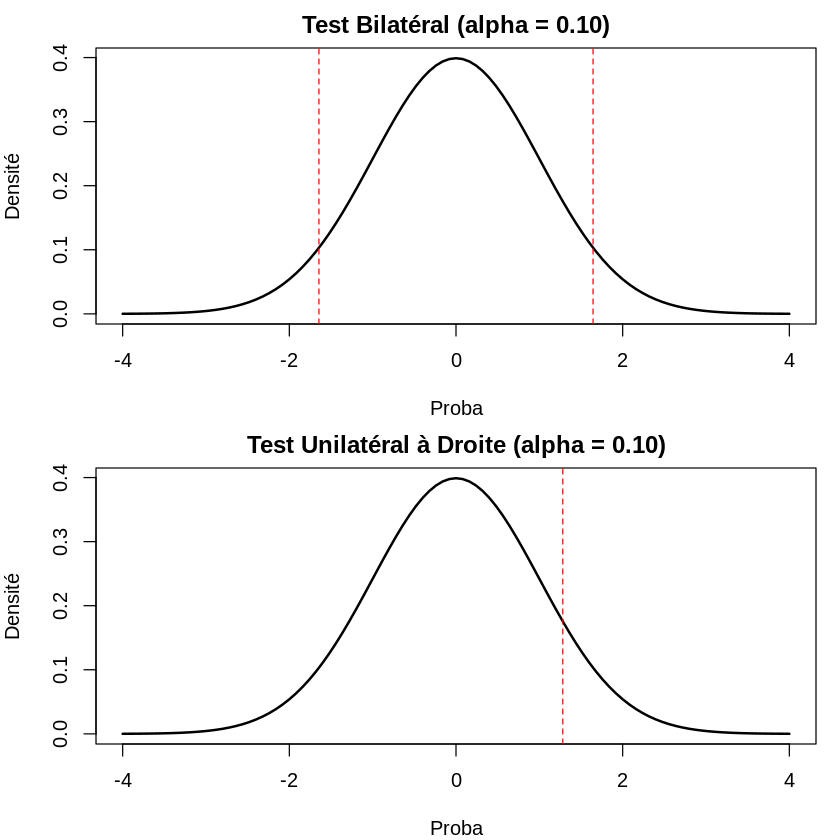

In [6]:
# Configuration pour afficher 2 graphiques l'un au-dessus de l'autre
#de l'illustration du cas bilaterale et unilatératle sur une gaussienne
par(mfrow=c(2,1), mar=c(4,4,2,1))

# 1. TEST BILATÉRAL (alpha = 0.10)
# alpha/2 = 0.05 de chaque côté
q_inf <- qnorm(0.05)
q_sup <- qnorm(0.95)

curve(dnorm(x), from=-4, to=4, main="Test Bilatéral (alpha = 0.10)",
      xlab="Proba", ylab="Densité", lwd=2)

abline(v=c(q_inf, q_sup), col="red", lty=2)

# 2. TEST UNILATÉRAL À DROITE (alpha = 0.10)
# alpha = 0.10 d'un seul côté
q_uni <- qnorm(0.90)

curve(dnorm(x), from=-4, to=4, main="Test Unilatéral à Droite (alpha = 0.10)",
      xlab="Proba", ylab="Densité", lwd=2)

abline(v=q_uni, col="red", lty=2)

par(mfrow=c(1,1))

In [7]:
help(t.test)
t.test(poids,alternative = "less",mu = 5,conf.level = 0.90)



	One Sample t-test

data:  poids
t = -1.7431, df = 13, p-value = 0.05245
alternative hypothesis: true mean is less than 5
90 percent confidence interval:
     -Inf 4.897273
sample estimates:
mean of x 
 4.544286 


Donc on reprend notre calcule de Zone de rejet ou nous avons notre alpha complet ici 0.1 :     
$$\mathcal{R} = \{ |Z| > q_{1-\alpha} \}$$

avec un degrès de liberté = 13, alpha =0.1
Ici notre |Z|=1.7431 et notre quantile d'après la table de student est égale à 1.350,avec alpha =0.1 , on accepte un risque de 10%.

$$\mathcal{R} = \{ |Z| > 1.350 \}$$

donc on se retrouve dans la zone de rejet et donc on rejette H0 .

### Test de Kolmogrov-Smirnov
Ce test vise à comparer l'accord d'un échantillons avec une loi de probabilité continue.
ici, D=sup

In [8]:
#6
#Test de Kolmogrov-Smirnov
ks.test(rnorm(50),"pnorm")


	Exact one-sample Kolmogorov-Smirnov test

data:  rnorm(50)
D = 0.099972, p-value = 0.6626
alternative hypothesis: two-sided


Ici notre p_valeur exprime qu'on ne peut pas rejeter l'hypothèse de normalité.Donc notre échantillon suit une loi normale.


In [9]:
#poids=c(5.71,4.29,3.46,3.09,2.69,4.88,5.77,4.90,4.27,5.14,3.96,4.91,4.74,5.81)
ks.test(poids,"pnorm",mean(poids),sd(poids))
# Attention ici pnorm est centré et réduite donc on doit aussi centré est réduire poids
#help(rnorm)


	Exact one-sample Kolmogorov-Smirnov test

data:  poids
D = 0.15072, p-value = 0.8626
alternative hypothesis: two-sided


Ici la p_value est assez éléeve largement supérieur à 0.1 donc on pourra pas rejeter l'hypothèse que notre échantillons est normale.

Maintenant on accepte la normalité de notre échantillons et reprend h0 et h1:
- H0: La moyenne des poids de loutre est égale à la moyenne de l'espece
- H1:La moyenne des poids des loutres est différentes celle de la moyenne de l'espèce .

### Estimateur du Maximum de Vraisemblance pour $\mu$

Les poids échantillon i.i.d., ils suivent une densité $\sim \mathcal{N}(\mu, \sigma^2)$

$$L(\mu, \sigma^2) = f(x_1, x_2, \dots, x_n ; \mu, \sigma^2)$$

Par indépendance (i.i.d.) :

$$= \prod_{i=1}^n f(x_i ; \mu, \sigma^2)$$

$$= \prod_{i=1}^n \left[ \frac{1}{\sqrt{2\pi\sigma^2}} \exp \left( - \frac{(x_i - \mu)^2}{2\sigma^2} \right) \right]$$

On sépare les termes :
* $\left( \frac{1}{(2\pi\sigma^2)^{1/2}} \right)^n = \frac{1}{(2\pi\sigma^2)^{n/2}} = (2\pi\sigma^2)^{-n/2}$
* $\prod_{i=1}^n \exp \left( - \frac{(x_i - \mu)^2}{2\sigma^2} \right) = \exp \left( - \sum_{i=1}^n \frac{(x_i - \mu)^2}{2\sigma^2} \right)$

Donc :

$$L(\mu, \sigma^2) = (2\pi\sigma^2)^{-n/2} \exp \left( - \sum_{i=1}^n \frac{(x_i - \mu)^2}{2\sigma^2} \right)$$

On passe au log (rappel : $\ln(a \cdot b) = \ln(a) + \ln(b)$) :

$$\ln (L(\mu, \sigma^2)) = - \frac{n}{2} \ln(2\pi\sigma^2) - \sum_{i=1}^n \frac{(x_i - \mu)^2}{2\sigma^2}$$

$$= - \frac{n}{2} \ln(2\pi) - \frac{n}{2} \ln(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^n (x_i - \mu)^2 \quad (*)$$

Dérivée par rapport à $\mu$ (sachant que $(u^2)' = 2uu'$):

$$\frac{\partial \ln(L(\mu, \sigma^2))}{\partial \mu} = \frac{1}{\sigma^2} \sum_{i=1}^n (x_i - \mu)$$

Comme on cherche le maximum de l'estimateur de vraisemblance (la pente s'annule) :

$$\sum_{i=1}^n (x_i - \mu) = 0$$

$$\sum_{i=1}^n x_i - n\mu = 0$$

$$-n\mu = - \sum_{i=1}^n x_i$$

$$\hat{\mu} = \frac{1}{n} \sum_{i=1}^n x_i$$

---

### Estimateur du Maximum de Vraisemblance pour $\sigma^2$

Dérivons $(*)$ par rapport à $\sigma^2$ :

$$\frac{\partial \ln(L(\cdot))}{\partial \sigma^2} = - \frac{n}{2\sigma^2} + \frac{1}{2\sigma^4} \sum (x_i - \mu)^2$$

La pente $= 0$, donc :

$$- \frac{n}{2\sigma^2} + \frac{1}{2\sigma^4} \sum (x_i - \mu)^2 = 0$$

$$\frac{1}{2\sigma^4} \sum_{i=1}^n (x_i - \mu)^2 = \frac{n}{2\sigma^2}$$

On isole la somme :

$$\sum_{i=1}^n (x_i - \mu)^2 = \frac{n}{2\sigma^2} \times 2\sigma^4$$

$$\sum_{i=1}^n (x_i - \mu)^2 = n\sigma^2$$

$$\frac{1}{n} \sum_{i=1}^n (x_i - \mu)^2 = \sigma^2$$

Ce qui nous donne l'estimateur $\hat{\sigma}^2$ (en remplaçant $\mu$ par son estimateur $\hat{\mu}$) :

$$\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^n (x_i - \hat{\mu})^2$$

**3. Rapport de vraisemblance ($\Lambda$) :**
Pour tester $H_0 : \mu = \mu_0$ contre $H_1 : \mu \neq \mu_0$, le rapport est :
$$\Lambda = \frac{L(\mu_0, \hat{\sigma}_0^2)}{L(\hat{\mu}, \hat{\sigma}^2)} = \left( \frac{\hat{\sigma}^2}{\hat{\sigma}_0^2} \right)^{n/2}$$
Où $\hat{\sigma}_0^2 = \frac{1}{n} \sum (x_i - \mu_0)^2$.

**4. Statistique de test et Région de rejet :**
On utilise la statistique de Student :
$$T = \frac{\bar{x} - \mu_0}{S / \sqrt{n}} \sim t(n-1)$$
Où $S = \sqrt{\frac{1}{n-1} \sum (x_i - \bar{x})^2}$ est l'écart-type échantillonnal corrigé.

La région de rejet au niveau $\alpha$ est :
$$\mathcal{R} = \left\{ |T| > t_{n-1, 1-\alpha/2} \right\}$$

---

###  Définition de $\alpha$

Le paramètre $\alpha$ représente le **risque de première espèce**. C'est la probabilité de rejeter l'hypothèse nulle $H_0$ alors qu'elle est en réalité vraie.
* **Concrètement :** Si $\alpha = 0.05$, on accepte de se tromper dans 5% des cas en affirmant qu'il y a une différence (ou un danger) alors qu'il n'y en a pas.

---

### Test de proportion (Loutres)

**Hypothèses :**
* $H_0 : p = 0.70$ (Stabilité génétique)
* $H_1 : p < 0.70$ (Risque de consanguinité/maladies)

**Statistique de test :**
Sous $H_0$, la statistique $Z$ suit approximativement une loi normale centrée réduite :
$$Z = \frac{\hat{p} - p_0}{\sqrt{\frac{p_0(1-p_0)}{n}}}$$
Avec $n = 140$, $x = 90$ et $\hat{p} = \frac{90}{140} \approx 0.643$.


In [11]:
prop.test(x = 90, n = 140, p = 0.70, alternative = "less")


	1-sample proportions test with continuity correction

data:  90 out of 140, null probability 0.7
X-squared = 1.9133, df = 1, p-value = 0.0833
alternative hypothesis: true p is less than 0.7
95 percent confidence interval:
 0.0000000 0.7095382
sample estimates:
        p 
0.6428571 


# Conclusion
Ce notebook a permis d'articuler les fondements théoriques de l'estimation par maximum de vraisemblance avec les réalités de l'analyse de données biologiques. Nous avons démontré comment la modélisation mathématique permet de définir des estimateurs optimaux pour la moyenne et la variance, constituant ainsi le socle nécessaire aux tests d'hypothèses. L'étude des populations de loutres a illustré l'importance cruciale de la gestion du risque $\alpha$ et de l'interprétation des p-values dans la prise de décision. Qu'il s'agisse de comparer des poids via le test de Student ou d'analyser la diversité génétique par des tests de proportion, la puissance statistique s'est révélée être un indicateur clé pour garantir la fiabilité de nos conclusions. Ce travail souligne que la statistique inférentielle est un outil indispensable pour transformer des observations brutes en connaissances scientifiques robustes et responsables.